# MPC

This notebook demonstrates the approximation of a non-linear Model Predictive Controller (MPC) using an Artificial Neural Network (ANN) built with PyTorch. 

The workflow consists of:
1. Generating a dataset using the optimal MPC on a rich reference sequence.
2. Training a Multi-Layer Perceptron (MLP) to map the parameter vector $P$ (historical states and future references) to the optimal control action $u^*$.
3. Validating the approximation in a simulated environment against the optimal MPC.
4. **Experimental Validation**: Comparing the simulated ANN controller against real-world experimental data obtained from a hardware-in-the-loop (HIL) dSpace setup running the original MPC.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from casadi import SX, MX, DM, Function, integrator, nlpsol, vertcat, horzcat
import time

def vcat(lst):
    return vertcat(*[DM(x) if not hasattr(x, 'is_symbolic') else x for x in lst])

## 1. NARX Model Definition
Define the discrete-time NARX model identified from the ball-and-beam dataset.

In [2]:
x = SX.sym('x', 5)
u = SX.sym('u', 1)

# x[0]=y(k), x[1]=y(k-1), x[2]=y(k-2), x[3]=u(k-1), x[4]=u(k-2)
# NARX model predicting y(k+1) using u(k)
y_next = 1.1440*x[0] - 0.0171*x[1] - 0.1534*x[2] + 0.2197*u - 0.1618 + 0.0015*(u**2)*x[3] + 0.0124*x[1]*x[3] + 0.0022*x[0]*x[1]*x[2] - 0.0452*x[4] - 0.0019*x[1]*(x[3]**2)
x_next = vertcat(y_next, x[0], x[1], u, x[3])

F = Function('F', [x, u], [x_next], ['x0', 'p'], ['xf'])

## 2. MPC NLP Formulation
Formulate the optimal control problem over a horizon $N=10$.

In [3]:
N = 10
nx = 5
nu = 1

data = {
    'Ts': 0.05,
    'x0': np.zeros(5),
    'u_min': -10.0,
    'u_max': 10.0,
    'x_min': np.array([-np.inf, -np.inf, -np.inf, -10.0, -10.0]),
    'x_max': np.array([np.inf, np.inf, np.inf, 10.0, 10.0]),
    'u_guess': 0.0,
    'x_guess': np.zeros(5),
    'tol': 1e-8,
}

w, lbw, ubw, w0 = [], [], [], []
g, lbg, ubg = [], [], []
J = 0
P = []
x_plot, u_plot = [], []

xk = MX.sym('x0', nx)
w.append(xk)
lbw.append(data['x_min'])
ubw.append(data['x_max'])
w0.append(data['x_guess'])

Pk = MX.sym('P0', nx)
g.append(xk - Pk)
lbg.append(np.zeros(nx))
ubg.append(np.zeros(nx))
P.append(Pk)
x_plot.append(xk)

for k in range(1, N + 1):
    uk = MX.sym(f'u{k}', nu)
    w.append(uk)
    lbw.append(data['u_min'])
    ubw.append(data['u_max'])
    w0.append(data['u_guess'])

    Fk = F(x0=xk, p=uk)
    xnext = Fk['xf']

    Pk = MX.sym(f'P{k}', 1)
    J = J + 1e3 * (xnext[0] - Pk)**2 + uk**2
    P.append(Pk)

    xk = MX.sym(f'x{k}', nx)
    w.append(xk)
    lbw.append(data['x_min'])
    ubw.append(data['x_max'])
    w0.append(data['x_guess'])
    g.append(xk - xnext)
    lbg.append(np.zeros(nx))
    ubg.append(np.zeros(nx))

    u_plot.append(uk)
    x_plot.append(xk)

w = vertcat(*w)
lbw = vcat(lbw)
ubw = vcat(ubw)
w0 = vcat(w0)
g = vertcat(*g)
lbg = vcat(lbg)
ubg = vcat(ubg)
P = vertcat(*P)

nlp = {'x': w, 'g': g, 'f': J, 'p': P}
solver = nlpsol('solver', 'ipopt', nlp, {'ipopt.print_level': 0, 'print_time': 0})

traj = Function('traj', [w], [horzcat(*x_plot), horzcat(*u_plot)], ['w'], ['x', 'u'])
warm = Function('warm', [horzcat(*x_plot), horzcat(*u_plot)], [w], ['x', 'u'], ['w'])

## 3. Dataset Generation
Generate a rich reference sequence for $T=300$ seconds to build the dataset.

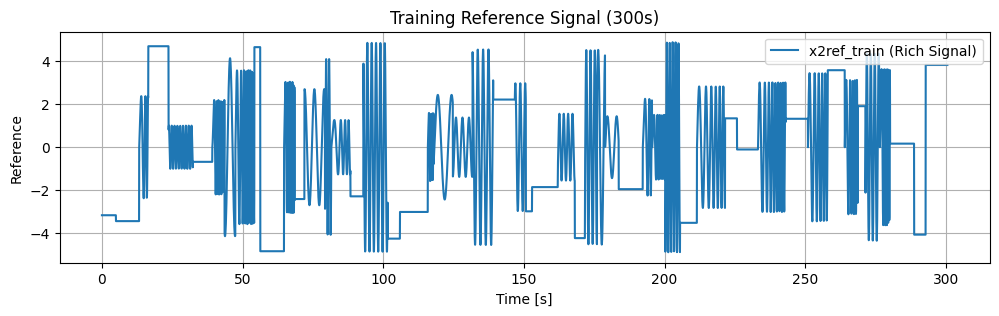

In [4]:
T_train = 300.0
steps_train = int(round(T_train / data['Ts']))
tvec_train = np.arange(0.0, T_train + N * data['Ts'] + data['Ts'], data['Ts'])

# Construct rich reference
np.random.seed(42)
x2ref_train = np.zeros_like(tvec_train)
t_idx = 0
while t_idx < len(tvec_train):
    duration = np.random.uniform(2.0, 10.0)
    idx_dur = int(round(duration / data['Ts']))
    segment_end = min(t_idx + idx_dur, len(tvec_train))
    
    sig_type = np.random.choice(['step', 'sine', 'chirp'])
    t_seg = tvec_train[t_idx:segment_end]
    
    if sig_type == 'step':
        val = np.random.uniform(-5.0, 5.0)
        x2ref_train[t_idx:segment_end] = val
    elif sig_type == 'sine':
        amp = np.random.uniform(1.0, 5.0)
        freq = np.random.uniform(0.1, 1.0)
        phase = np.random.uniform(0, 2*np.pi)
        x2ref_train[t_idx:segment_end] = amp * np.sin(2 * np.pi * freq * t_seg + phase)
    else: # chirp-like
        amp = np.random.uniform(1.0, 4.0)
        freq_start = np.random.uniform(0.1, 0.5)
        freq_end = np.random.uniform(0.5, 2.0)
        instant_freq = np.linspace(freq_start, freq_end, segment_end - t_idx)
        x2ref_train[t_idx:segment_end] = amp * np.sin(2 * np.pi * instant_freq * (t_seg - t_seg[0]))
        
    t_idx = segment_end

plt.figure(figsize=(12, 3))
plt.plot(tvec_train, x2ref_train, label='x2ref_train (Rich Signal)')
plt.xlabel('Time [s]')
plt.ylabel('Reference')
plt.title('Training Reference Signal (300s)')
plt.legend()
plt.grid(True)
plt.show()

Run the MPC over the training reference to collect the optimal parameter vectors $P$ and control actions $U$.

Generating MPC dataset over 6000 steps...

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************



Step 1000/6000 completed.


Step 2000/6000 completed.


Step 3000/6000 completed.


Step 4000/6000 completed.


Step 5000/6000 completed.


Step 6000/6000 completed.
Dataset generated. X shape: (6000, 15), Y shape: (6000,)


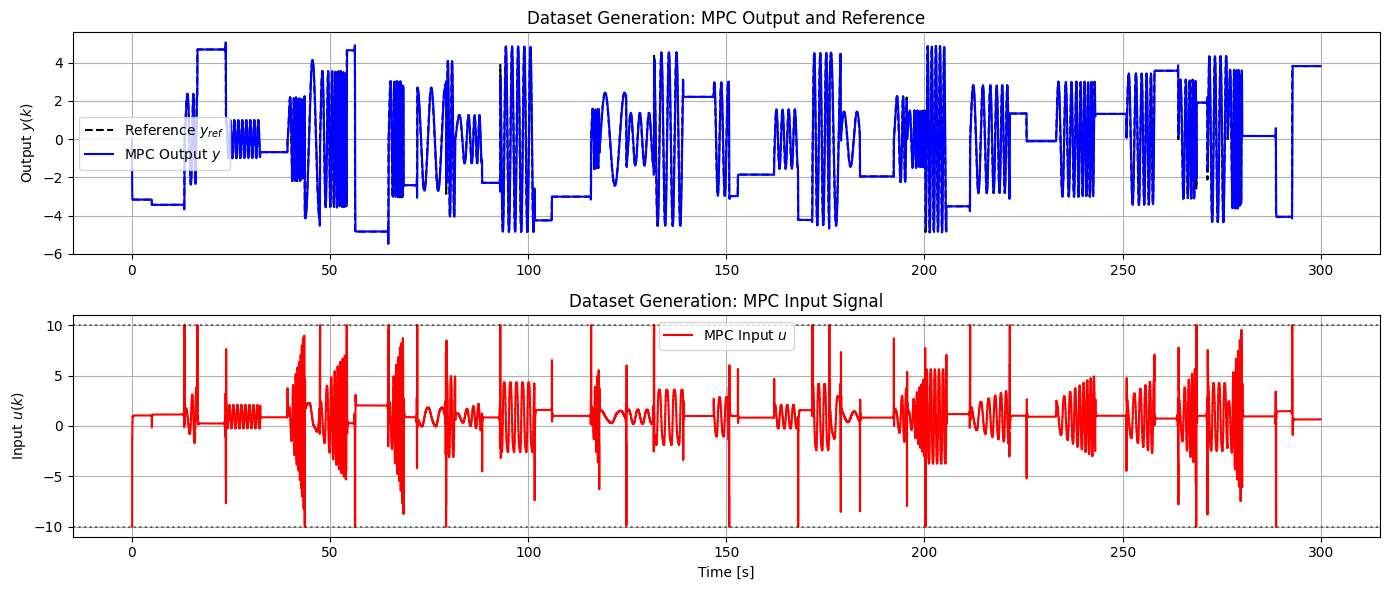

In [5]:
print(f"Generating MPC dataset over {steps_train} steps...")

X_data = []
Y_data = []

xsim = data['x0'].reshape(-1, 1)
w0_train = w0

for k in range(steps_train):
    x2refvec = x2ref_train[k:k + N]
    pval = np.r_[xsim[:, -1], x2refvec]
    
    sol = solver(x0=w0_train, lbx=lbw, ubx=ubw, lbg=lbg, ubg=ubg, p=DM(pval))
    
    x_opt, u_opt = traj(sol['x'])
    u_opt = np.array(u_opt.full())
    uk = u_opt[:, 0]
    
    X_data.append(pval)
    Y_data.append(uk[0])
    
    xk1 = np.array(F(x0=DM(xsim[:, -1]), p=DM(uk))['xf'].full()).reshape(-1)
    xsim = np.c_[xsim, xk1]
    
    x_ws = np.c_[x_opt[:, 1:], x_opt[:, -1]]
    u_ws = np.c_[u_opt[:, 1:], u_opt[:, -1]]
    w0_train = warm(x=x_ws, u=u_ws)['w']
    
    if (k+1) % 1000 == 0:
        print(f"Step {k+1}/{steps_train} completed.")

X_data = np.array(X_data)
Y_data = np.array(Y_data)

print(f"Dataset generated. X shape: {X_data.shape}, Y shape: {Y_data.shape}")

plt.figure(figsize=(14, 6))

# Plot Output vs Reference
plt.subplot(2, 1, 1)
plt.plot(tvec_train[:steps_train], x2ref_train[:steps_train], 'k--', label='Reference $y_{ref}$')
plt.plot(tvec_train[:steps_train], xsim[0, :-1], 'b-', label='MPC Output $y$')
plt.ylabel('Output $y(k)$')
plt.title('Dataset Generation: MPC Output and Reference')
plt.grid(True)
plt.legend()

# Plot Input Signal
plt.subplot(2, 1, 2)
plt.step(tvec_train[:steps_train], Y_data, 'r-', where='post', label='MPC Input $u$')
plt.axhline(data['u_max'], color='k', linestyle=':', alpha=0.5)
plt.axhline(data['u_min'], color='k', linestyle=':', alpha=0.5)
plt.xlabel('Time [s]')
plt.ylabel('Input $u(k)$')
plt.title('Dataset Generation: MPC Input Signal')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

## 4. Train the Artificial Neural Network (PyTorch)
We will use PyTorch to build a Multi-Layer Perceptron (MLP) to map $X \to Y$. 
We normalize the inputs using `StandardScaler`.

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_data)

X_train, X_val, y_train, y_val = train_test_split(X_scaled, Y_data, test_size=0.1, random_state=42)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)

train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

class MPCNet(nn.Module):
    def __init__(self):
        super(MPCNet, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(15, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.net(x)

model = MPCNet()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 150
print("Training PyTorch Model...")
for epoch in range(epochs):
    model.train()
    epoch_loss = 0.0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * batch_x.size(0)
    
    epoch_loss /= len(train_loader.dataset)
    
    if (epoch+1) % 25 == 0:
        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val_t), y_val_t).item()
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {epoch_loss:.4f} | Val Loss: {val_loss:.4f}")

model.eval()
with torch.no_grad():
    y_train_pred = model(X_train_t)
    train_mse = criterion(y_train_pred, y_train_t).item()
    val_mse = criterion(model(X_val_t), y_val_t).item()
print(f"Final Train MSE: {train_mse:.6f}")
print(f"Final Val MSE: {val_mse:.6f}")

Training PyTorch Model...


Epoch 25/150 | Train Loss: 0.0831 | Val Loss: 0.1257


Epoch 50/150 | Train Loss: 0.0381 | Val Loss: 0.0878


Epoch 75/150 | Train Loss: 0.0232 | Val Loss: 0.0708


Epoch 100/150 | Train Loss: 0.0176 | Val Loss: 0.0805


Epoch 125/150 | Train Loss: 0.0163 | Val Loss: 0.0668


Epoch 150/150 | Train Loss: 0.0099 | Val Loss: 0.0664
Final Train MSE: 0.012486
Final Val MSE: 0.066366


## 5. Validation Simulation (Optimal MPC vs ANN)
Now we create a new, unseen reference test signal for $T=20s$.
We will run two side-by-side simulations to compare the tracking performance and control effort.

In [7]:
T_test = 20.0
steps_test = int(round(T_test / data['Ts']))
tvec_test = np.arange(0.0, T_test + N * data['Ts'] + data['Ts'], data['Ts'])

# New test reference (unseen combination)
x2ref_test = np.zeros_like(tvec_test)
x2ref_test[tvec_test < 5] = 2.0
x2ref_test[(tvec_test >= 5) & (tvec_test < 12)] = -3.0
x2ref_test[(tvec_test >= 12) & (tvec_test < 16)] = 4.0 * np.sin(2 * np.pi * 0.5 * tvec_test[(tvec_test >= 12) & (tvec_test < 16)])
x2ref_test[tvec_test >= 16] = 1.0

# Arrays for logging MPC
xsim_mpc = data['x0'].reshape(-1, 1)
usim_mpc = []
dtvec_mpc = []
w0_test = w0

# Arrays for logging ANN
xsim_ann = data['x0'].reshape(-1, 1)
usim_ann = []
dtvec_ann = []

print("Running Validation Simulations...")

for k in range(steps_test):
    x2refvec = x2ref_test[k:k + N]
    
    # ---------------------------
    # SIMULATION A: Optimal MPC
    # ---------------------------
    pval_mpc = np.r_[xsim_mpc[:, -1], x2refvec]
    
    tic = time.perf_counter()
    sol = solver(x0=w0_test, lbx=lbw, ubx=ubw, lbg=lbg, ubg=ubg, p=DM(pval_mpc))
    dtvec_mpc.append(time.perf_counter() - tic)
    
    x_opt, u_opt = traj(sol['x'])
    u_opt = np.array(u_opt.full())
    uk_mpc = u_opt[:, 0]
    
    xk1_mpc = np.array(F(x0=DM(xsim_mpc[:, -1]), p=DM(uk_mpc))['xf'].full()).reshape(-1)
    xsim_mpc = np.c_[xsim_mpc, xk1_mpc]
    usim_mpc.append(uk_mpc)
    
    x_ws = np.c_[x_opt[:, 1:], x_opt[:, -1]]
    u_ws = np.c_[u_opt[:, 1:], u_opt[:, -1]]
    w0_test = warm(x=x_ws, u=u_ws)['w']
    
    # ---------------------------
    # SIMULATION B: Approximate ANN (PyTorch)
    # ---------------------------
    pval_ann = np.r_[xsim_ann[:, -1], x2refvec]
    
    tic = time.perf_counter()
    pval_scaled = scaler.transform(pval_ann.reshape(1, -1))
    pval_t = torch.tensor(pval_scaled, dtype=torch.float32)
    with torch.no_grad():
        uk_ann_val = model(pval_t).item()
    dtvec_ann.append(time.perf_counter() - tic)
    
    # Bound the ANN output to strictly respect u_min and u_max
    uk_ann = np.array([np.clip(uk_ann_val, data['u_min'], data['u_max'])])
    
    xk1_ann = np.array(F(x0=DM(xsim_ann[:, -1]), p=DM(uk_ann))['xf'].full()).reshape(-1)
    xsim_ann = np.c_[xsim_ann, xk1_ann]
    usim_ann.append(uk_ann)

xsim_mpc = xsim_mpc[:, :-1]
usim_mpc = np.array(usim_mpc).T
xsim_ann = xsim_ann[:, :-1]
usim_ann = np.array(usim_ann).T
tvec_plot = np.array(tvec_test[:steps_test])

print(f"Average MPC Solve Time: {np.mean(dtvec_mpc)*1000:.2f} ms")
print(f"Average ANN Predict Time: {np.mean(dtvec_ann)*1000:.2f} ms")
print(f"Speedup Factor: {np.mean(dtvec_mpc)/np.mean(dtvec_ann):.2f}x")

Running Validation Simulations...


Average MPC Solve Time: 2.32 ms
Average ANN Predict Time: 0.11 ms
Speedup Factor: 22.05x


## 6. Results & Comparison

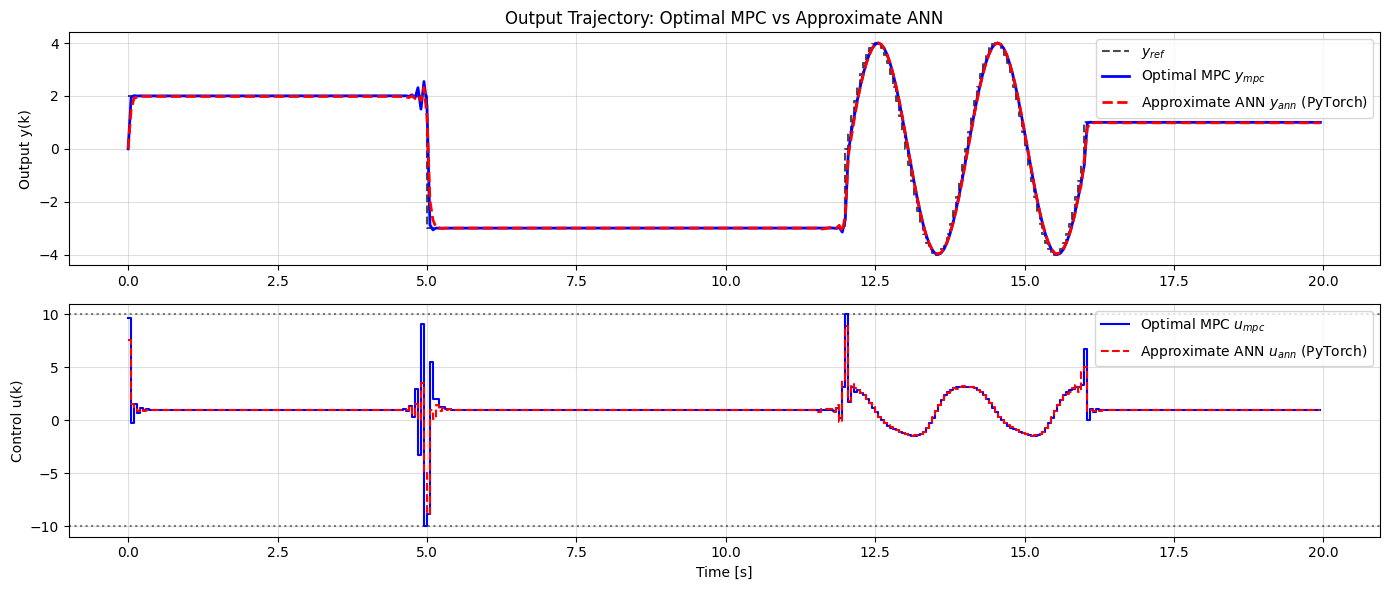

In [8]:
a = x2ref_test[:steps_test]

plt.figure(figsize=(14, 6))

# Plot 1: Output Trajectory Comparison
plt.subplot(2, 1, 1)
plt.step(tvec_plot, a, where='post', color='k', linestyle='--', label='$y_{ref}$', alpha=0.7)
plt.plot(tvec_plot, xsim_mpc[0, :], 'b-', linewidth=2, label='Optimal MPC $y_{mpc}$')
plt.plot(tvec_plot, xsim_ann[0, :], 'r--', linewidth=2, label='Approximate ANN $y_{ann}$ (PyTorch)')
plt.grid(True, alpha=0.4)
plt.ylabel('Output y(k)')
plt.legend(loc='upper right')
plt.title('Output Trajectory: Optimal MPC vs Approximate ANN')

# Plot 2: Control Effort Comparison
plt.subplot(2, 1, 2)
plt.step(tvec_plot, usim_mpc[0, :], where='post', color='b', label='Optimal MPC $u_{mpc}$')
plt.step(tvec_plot, usim_ann[0, :], where='post', color='r', linestyle='--', label='Approximate ANN $u_{ann}$ (PyTorch)')
plt.axhline(data['u_max'], color='k', linestyle=':', alpha=0.5)
plt.axhline(data['u_min'], color='k', linestyle=':', alpha=0.5)
plt.grid(True, alpha=0.4)
plt.xlabel('Time [s]')
plt.ylabel('Control u(k)')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

As seen above, the PyTorch neural network successfully approximates the non-linear MPC behavior while performing inferences significantly faster.

## 7. Experimental Validation against dSpace MPC

To verify the real-world applicability of our approximate controller, we load experimental data from a Hardware-in-the-Loop (HIL) implementation of the exact same MPC running on a **dSpace** system. 

We will:
1. Extract the experimental reference signal and the corresponding optimal control actions applied by the hardware MPC.
2. Run a closed-loop simulation using our PyTorch ANN model fed with the exact same reference trajectory.
3. Compare the control effort and output trajectory of the **Approximate ANN (Simulated)** with the **Experimental MPC (dSpace)**.

*Note: The experimental data was sampled at 1 kHz, whereas our ANN was designed for 20 Hz ($T_s = 0.05$ s). We will downsample the experimental data accordingly before feeding it to the ANN.*

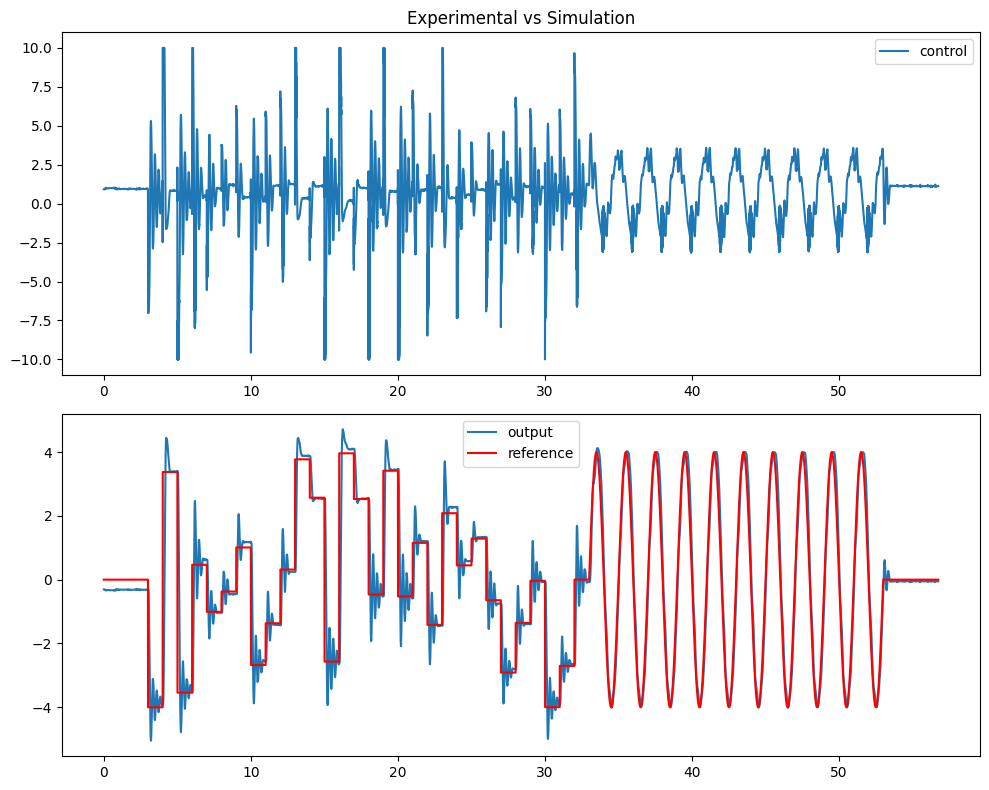

In [9]:
import h5py
import matplotlib.pyplot as plt
import numpy as np

# Load the .mat file (v7.3 format requires h5py)
f = h5py.File('data/ball_and_beam/aquisicao_02_mpc_modelo_NARX.mat', 'r')
data = f['aquisicao_02_mpc_modelo_NARX']

# Extract t (X data)
t = np.array(data['X']['Data']).flatten()

# Extract u, y2, y3 (Y data references)
y_refs = data['Y']['Data']
u = np.array(f[y_refs[0][0]]).flatten()
y2 = np.array(f[y_refs[1][0]]).flatten()
y3 = np.array(f[y_refs[2][0]]).flatten()

# Plotting
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

ax1.plot(t, u, label='control')
ax1.legend()
ax1.set_title('Experimental vs Simulation')

ax2.plot(t, y2, label='output')
ax2.plot(t, y3, 'r', label='reference')
ax2.legend()

plt.tight_layout()
plt.show()

Simulating ANN controller on experimental reference...
MSE Control (Approximate ANN vs Experimental MPC): 2.7352
MSE Output (Approximate ANN vs Experimental MPC): 0.1636


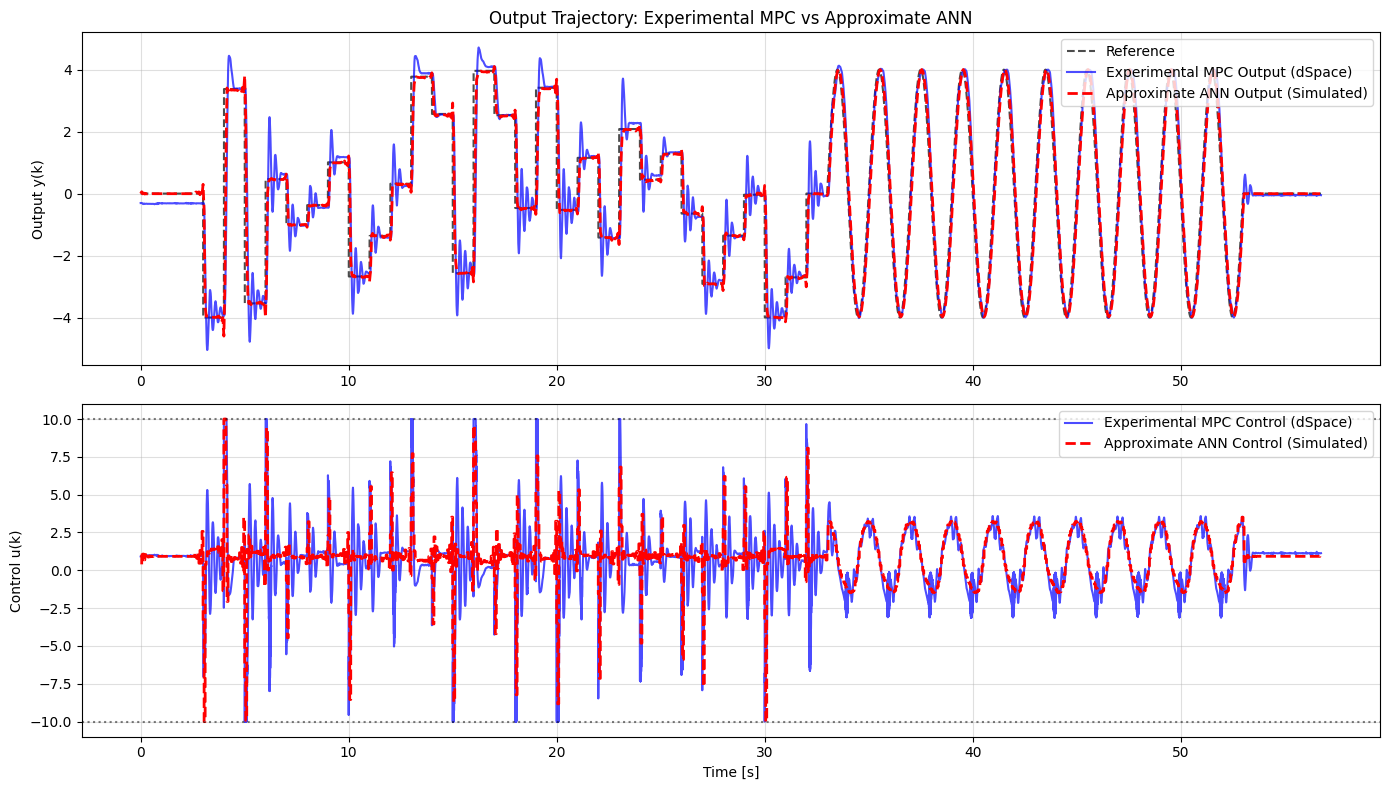

In [10]:
import numpy as np
import torch
import time
from casadi import DM
import matplotlib.pyplot as plt

# The dSpace experimental data is sampled at 1 kHz (dt=0.001s), but our model runs at 20 Hz (Ts=0.05s)
# We perform a downsampling by a factor of 50 to match the ANN's frequency
downsample_factor = 50

# Experimental data loaded from the .mat file
t_exp = t
u_exp = u
y_exp = y2
ref_exp = y3

t_down = t_exp[::downsample_factor]
ref_down = ref_exp[::downsample_factor]
u_down = u_exp[::downsample_factor]
y_down = y_exp[::downsample_factor]

# Pad the reference with its last value to ensure we have the prediction horizon 'N' at the end
ref_padded = np.pad(ref_down, (0, N), 'edge')

# Variables to store the ANN simulation results
xsim_ann_exp = np.zeros(5).reshape(-1, 1)
usim_ann_exp = []
dtvec_ann_exp = []

steps_exp = len(t_down)

print("Simulating ANN controller on experimental reference...")

for k in range(steps_exp):
    x2refvec = ref_padded[k:k + N]
    
    pval_ann = np.r_[xsim_ann_exp[:, -1], x2refvec]
    
    tic = time.perf_counter()
    pval_scaled = scaler.transform(pval_ann.reshape(1, -1))
    pval_t = torch.tensor(pval_scaled, dtype=torch.float32)
    with torch.no_grad():
        uk_ann_val = model(pval_t).item()
    dtvec_ann_exp.append(time.perf_counter() - tic)
    
    # Enforce physical constraints on the control signal
    uk_ann = np.array([np.clip(uk_ann_val, -10.0, 10.0)])
    
    # Update the system state using the NARX model
    xk1_ann = np.array(F(x0=DM(xsim_ann_exp[:, -1]), p=DM(uk_ann))['xf'].full()).reshape(-1)
    xsim_ann_exp = np.c_[xsim_ann_exp, xk1_ann]
    usim_ann_exp.append(uk_ann)

xsim_ann_exp = xsim_ann_exp[:, :-1]
usim_ann_exp = np.array(usim_ann_exp).T

# Error Metrics
mse_u = np.mean((usim_ann_exp[0, :] - u_down)**2)
mse_y = np.mean((xsim_ann_exp[0, :] - y_down)**2)
print(f"MSE Control (Approximate ANN vs Experimental MPC): {mse_u:.4f}")
print(f"MSE Output (Approximate ANN vs Experimental MPC): {mse_y:.4f}")

# Plotting the Comparison
plt.figure(figsize=(14, 8))

plt.subplot(2, 1, 1)
plt.plot(t_exp, ref_exp, 'k--', label='Reference', alpha=0.7)
plt.plot(t_exp, y_exp, 'b-', label='Experimental MPC Output (dSpace)', alpha=0.7)
plt.plot(t_down, xsim_ann_exp[0, :], 'r--', linewidth=2, label='Approximate ANN Output (Simulated)')
plt.ylabel('Output y(k)')
plt.title('Output Trajectory: Experimental MPC vs Approximate ANN')
plt.grid(True, alpha=0.4)
plt.legend(loc='upper right')

plt.subplot(2, 1, 2)
plt.plot(t_exp, u_exp, 'b-', label='Experimental MPC Control (dSpace)', alpha=0.7)
plt.step(t_down, usim_ann_exp[0, :], where='post', color='r', linestyle='--', linewidth=2, label='Approximate ANN Control (Simulated)')
plt.axhline(10.0, color='k', linestyle=':', alpha=0.5)
plt.axhline(-10.0, color='k', linestyle=':', alpha=0.5)
plt.ylabel('Control u(k)')
plt.xlabel('Time [s]')
plt.grid(True, alpha=0.4)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()